# 課題と解答例：単一薄板の2次元温度場

元Notebook：[単一薄板](../12_stegosaurus_single_plate_2d.ipynb)

上から順に実行できる．課題に必要な基準関数もこのNotebookに含める．

## 課題：関数の実装と検証

1. `solve_rectangular_plate_general(k_value, h_value, thickness_value, dx)` を作る．基準ソルバーへ引数を渡して呼び出し，体積と `Q_out` を体積で割った値を戻り値に追加する．グローバル変数を書き換えず，基準条件の放熱量が一致することを検証する．
2. `parameter_sweep(parameter_name, values, dx)` を作り，各条件の `Q_out`，`Q_base`，先端境界の中央温度，収支誤差，`Bi_t` をDataFrameで返す．1つのパラメータだけを変え，ほかを固定する．
3. 格子幅を3段階以上で変えた表を作り，最細格子との差を `relative difference from finest Q` 列に追加する．厳密解に対する誤差との違いを説明する．さらに左右・先端断熱の検証条件で解析値との相対誤差と観測収束次数を計算する．
4. 根元中央の幅0.08 mだけを加熱する `is_base_fixed(ix, x)` を作り，`base_selector` に渡して実行する．ソルバー内でどの辺の条件が切り替わるかをコードコメントで説明する．加熱しない下端は空気に接し，`h_value` で対流する条件である．全幅加熱との温度場・放熱量の違いと，実際の加熱幅の格子依存性を調べる．
5. 温度が `[T_air, T_base]` に収まること，左右対称性，全対流係数を0にすると一様温度になることを `np.testing.assert_allclose` や `assert` で検証する．熱流が0の場合は相対収支誤差を使わず，絶対差を確認する．

## 解答例の準備

以下は元Notebookと同じパラメータとセル中心有限体積法のソルバーである．

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# 計算練習用の仮定値であり，背板の実測値ではない．
k = 20.0          # thermal conductivity [W/(m K)]
h = 25.0          # convection coefficient [W/(m^2 K)]
T_base = 40.0     # root temperature [degC]
T_air = 25.0      # air temperature [degC]
height = 0.40     # plate height [m]
width = 0.18      # plate width [m]
thickness = 0.02  # plate thickness [m]
print(f'Bi_t = {h*thickness/(2*k):.4f}')

from IPython.display import display

def solve_rectangular_plate(dx=0.005, h_value=h, *, k_value=k,
                            thickness_value=thickness, h_side=None, h_tip=None,
                            base_selector=None):
    """セル中心の過剰温度を解く．dx は希望する最大格子幅である．

    h_side と h_tip を0にすると左右・先端が断熱になる．
    base_selector(ix, x) がFalseの下端は空気に接し，h_valueで対流する．
    """
    h_side = h_value if h_side is None else h_side
    h_tip = h_value if h_tip is None else h_tip
    values = [dx, h_value, k_value, thickness_value, h_side, h_tip]
    if not np.all(np.isfinite(values)) or min(dx, k_value, thickness_value) <= 0:
        raise ValueError('Require finite inputs and positive dx, k, thickness')
    if min(h_value, h_side, h_tip) < 0:
        raise ValueError('Convection coefficients must be nonnegative')
    # 端点をセル中心として数えず，指定された領域をちょうど覆う．
    nx = max(1, int(np.ceil(width / dx)))
    ny = max(1, int(np.ceil(height / dx)))
    dx_cell, dy_cell = width / nx, height / ny
    x = -width / 2 + (np.arange(nx) + 0.5) * dx_cell
    y = (np.arange(ny) + 0.5) * dy_cell
    fixed_base = np.array([base_selector(ix, x) if base_selector else True
                           for ix in range(nx)], dtype=bool)
    if not fixed_base.any():
        raise ValueError('At least one base face must be heated')
    index = np.arange(nx * ny).reshape(ny, nx)
    A = lil_matrix((nx * ny, nx * ny))
    b = np.zeros(nx * ny)
    theta_b = T_base - T_air
    kt = k_value * thickness_value
    g_x = kt * dy_cell / dx_cell
    g_y = kt * dx_cell / dy_cell
    g_face = 2 * h_value * dx_cell * dy_cell
    g_base = kt * dx_cell / (dy_cell / 2)

    def edge_conductance(h_edge, edge_length, distance):
        return h_edge * thickness_value * edge_length / (1 + h_edge * distance / k_value)

    g_side = edge_conductance(h_side, dy_cell, dx_cell / 2)
    g_tip = edge_conductance(h_tip, dx_cell, dy_cell / 2)
    g_bottom = edge_conductance(h_value, dx_cell, dy_cell / 2)
    # 下，上，左，右の順で，セル間の伝導を数える．
    directions = [(-1, 0, g_y), (1, 0, g_y), (0, -1, g_x), (0, 1, g_x)]
    for iy in range(ny):
        for ix in range(nx):
            p = index[iy, ix]
            diagonal = g_face
            for diy, dix, g_cond in directions:
                jy, jx = iy + diy, ix + dix
                if 0 <= jy < ny and 0 <= jx < nx:
                    diagonal += g_cond
                    A[p, index[jy, jx]] = -g_cond
                elif diy == -1:  # y=0 の物理境界面
                    if fixed_base[ix]:
                        diagonal += g_base
                        b[p] += g_base * theta_b
                    else:
                        diagonal += g_bottom
                elif diy == 1:
                    diagonal += g_tip
                else:
                    diagonal += g_side
            A[p, p] = diagonal

    A = A.tocsr()
    theta_vector = spsolve(A, b)
    theta = theta_vector.reshape(ny, nx)
    # 根元面の流入と，両面・空気に触れる各外周面の流出を別々に集計する．
    q_face = g_face * theta.sum()
    q_edge = (g_side * (theta[:, 0].sum() + theta[:, -1].sum())
              + g_tip * theta[-1, :].sum()
              + g_bottom * theta[0, ~fixed_base].sum())
    q_out = q_face + q_edge
    q_base = g_base * (theta_b - theta[0, fixed_base]).sum()
    balance_absolute = abs(q_base - q_out)
    heat_scale = max(abs(q_out), abs(q_base))
    # 熱流がほぼ0の場合は相対誤差を定義せず，絶対誤差を参照する．
    has_heat_loss = max(h_value, h_side, h_tip) > 0 and theta_b != 0
    balance_relative = balance_absolute / heat_scale if has_heat_loss and heat_scale > 1e-12 else np.nan
    tip_temperature = T_air + theta[-1, :] / (1 + h_tip * dy_cell / (2*k_value))
    residual = np.linalg.norm(A @ theta_vector - b, ord=np.inf)
    rhs_norm = np.linalg.norm(b, ord=np.inf)
    return {
        'x': x, 'y': y, 'temperature': T_air + theta,
        'tip_temperature': tip_temperature,
        'local_face_flux': 2*h_value*theta,
        'Q_face': q_face, 'Q_edge': q_edge, 'Q_out': q_out, 'Q_base': q_base,
        'balance_error': balance_relative, 'balance_absolute': balance_absolute,
        'linear_residual': residual / rhs_norm if rhs_norm > 0 else residual,
        'dx': dx_cell, 'dy': dy_cell, 'dx_requested': dx,
        'area': nx*ny*dx_cell*dy_cell, 'heated_base_width': fixed_base.sum()*dx_cell,
        'h': h_value, 'k': k_value, 'thickness': thickness_value,
        'Bi_t': h_value*thickness_value/(2*k_value),
    }


result = solve_rectangular_plate()
print(f"Q_base = {result['Q_base']:.6f} W, Q_out = {result['Q_out']:.6f} W")
print(f"Q_face = {result['Q_face']:.6f} W, Q_edge = {result['Q_edge']:.6f} W")
print(f"relative energy-balance error = {result['balance_error']:.3e}")
print(f"area = {result['area']:.6f} m^2, exact area = {width*height:.6f} m^2")

Bi_t = 0.0125
Q_base = 12.705713 W, Q_out = 12.705713 W
Q_face = 11.447518 W, Q_edge = 1.258195 W
relative energy-balance error = 1.809e-13
area = 0.072000 m^2, exact area = 0.072000 m^2


## パラメータ変更の実装例

In [2]:
def solve_rectangular_plate_general(k_value=k, h_value=h, thickness_value=thickness, dx=0.005):
    r = solve_rectangular_plate(dx=dx, k_value=k_value, h_value=h_value,
                                thickness_value=thickness_value)
    r['volume'] = r['area'] * thickness_value
    r['Q_per_volume'] = r['Q_out'] / r['volume']
    return r


def parameter_sweep(parameter_name, values, dx=0.005):
    if parameter_name not in {'k_value', 'h_value', 'thickness_value'}:
        raise ValueError('Unknown parameter')
    rows = []
    for value in values:
        args = dict(k_value=k, h_value=h, thickness_value=thickness, dx=dx)
        args[parameter_name] = value
        r = solve_rectangular_plate_general(**args)
        rows.append({parameter_name: value, 'Q_out [W]': r['Q_out'], 'Q_base [W]': r['Q_base'],
                     'tip T [degC]': np.interp(0, r['x'], r['tip_temperature']),
                     'balance error': r['balance_error'], 'Bi_t': r['Bi_t']})
    return pd.DataFrame(rows)


baseline = solve_rectangular_plate()
np.testing.assert_allclose(solve_rectangular_plate_general()['Q_out'], baseline['Q_out'])
display(parameter_sweep('k_value', [10, 20, 40]))

,k_value,Q_out [W],Q_base [W],tip T [degC],balance error,Bi_t
0,10,8.974335,8.974335,25.035215,1.326181e-14,0.02500
1,20,12.705713,12.705713,25.249861,1.809112e-13,0.01250
2,40,17.944413,17.944413,26.006832,1.736323e-13,0.00625


## 最細格子との差と解析解の誤差

最細格子との差が0になる行は，真の誤差が0という意味ではない．解析解を使う検証では，元とは異なる左右・先端断熱の境界条件に切り替える．

In [3]:
rows = []
for dx_try in [0.010, 0.005, 0.0025]:
    r = solve_rectangular_plate(dx=dx_try)
    rows.append({'dx [m]': r['dx'], 'dy [m]': r['dy'], 'area [m^2]': r['area'],
                 'Q_out [W]': r['Q_out'], 'Q_base [W]': r['Q_base'],
                 'balance error': r['balance_error'],
                 'tip T [degC]': np.interp(0, r['x'], r['tip_temperature'])})
convergence = pd.DataFrame(rows)
q_ref = convergence.iloc[-1]['Q_out [W]']
convergence['relative difference from finest Q'] = abs(convergence['Q_out [W]']-q_ref)/abs(q_ref)
convergence

,dx [m],dy [m],area [m^2],Q_out [W],Q_base [W],balance error,tip T [degC],relative difference from finest Q
0,0.0100,0.0100,0.072,12.688702,12.688702,2.001931e-14,25.250305,0.001677
1,0.0050,0.0050,0.072,12.705713,12.705713,1.809112e-13,25.249861,0.000338
2,0.0025,0.0025,0.072,12.710014,12.710014,6.567342e-13,25.249749,0.000000


In [4]:
mu = np.sqrt(2*h/(k*thickness))
theta_b = T_base - T_air
q_exact = k*thickness*width*mu*theta_b*np.tanh(mu*height)
rows = []
for dx_try in [0.010, 0.005, 0.0025]:
    r = solve_rectangular_plate(dx=dx_try, h_side=0.0, h_tip=0.0)
    yy = r['y']
    exact = theta_b * (np.exp(-mu*yy) + np.exp(-mu*(2*height-yy))) / (1+np.exp(-2*mu*height))
    t_error = np.max(np.abs(r['temperature']-(T_air+exact[:, None]))) / theta_b
    rows.append({'dx [m]': r['dx'], 'relative T error': t_error,
                 'relative Q error': abs(r['Q_out']-q_exact)/q_exact,
                 'balance error': r['balance_error']})
benchmark = pd.DataFrame(rows)
benchmark['observed T order'] = np.log2(benchmark['relative T error'].shift(1)/benchmark['relative T error'])
benchmark['observed Q order'] = np.log2(benchmark['relative Q error'].shift(1)/benchmark['relative Q error'])
benchmark

,dx [m],relative T error,relative Q error,balance error,observed T order,observed Q order
0,0.0100,0.001447,0.001560,1.827530e-14,NaN,NaN
1,0.0050,0.000376,0.000391,2.055038e-13,1.943507,1.997470
2,0.0025,0.000096,0.000098,7.184640e-13,1.972429,1.999367


## 部分加熱と自動検証の実装例

下端の加熱区間以外は対流面である．共通の色範囲で温度場を比較し，熱供給幅の変更と輪郭の変更を区別する．

,dx [m],heated width [m],Q_out [W],balance error
0,0.0100,0.08,9.599618,1.683905e-14
1,0.0050,0.08,9.813088,1.621932e-13
2,0.0025,0.08,9.918170,6.399288e-13


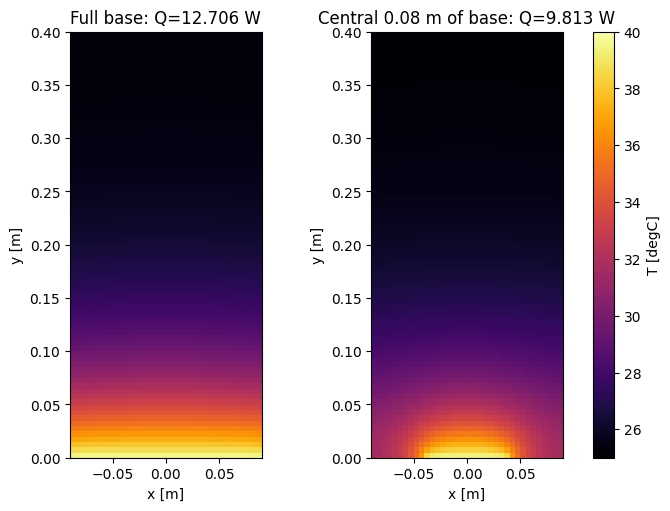

Temperature bounds, symmetry, and the insulated limit: OK


In [5]:
def is_base_fixed(ix, x):
    return abs(x[ix]) < 0.04


# ソルバーの下向きの辺 diy == -1 で，固定温度面と対流面が切り替わる．
# セル中心を直接固定する条件ではない．
partial = solve_rectangular_plate(base_selector=is_base_fixed)
rows = []
for dx_try in [0.01, 0.005, 0.0025]:
    r = solve_rectangular_plate(dx=dx_try, base_selector=is_base_fixed)
    rows.append({'dx [m]': r['dx'], 'heated width [m]': r['heated_base_width'],
                 'Q_out [W]': r['Q_out'], 'balance error': r['balance_error']})
display(pd.DataFrame(rows))
fig, axes = plt.subplots(1, 2, figsize=(7, 5), constrained_layout=True)
for ax, r, title in zip(axes, [baseline, partial], ['Full base', 'Central 0.08 m of base']):
    im = ax.imshow(r['temperature'], origin='lower', extent=[-width/2, width/2, 0, height],
                   vmin=T_air, vmax=T_base, cmap='inferno', aspect='equal')
    ax.set(title=f'{title}: Q={r["Q_out"]:.3f} W', xlabel='x [m]', ylabel='y [m]')
fig.colorbar(im, ax=axes, label='T [degC]')
plt.show()

temperature = baseline['temperature']
assert temperature.min() >= T_air - 1e-9
assert temperature.max() <= T_base + 1e-9
np.testing.assert_allclose(temperature, temperature[:, ::-1], atol=1e-9, rtol=0)
insulated = solve_rectangular_plate(h_value=0, h_side=0, h_tip=0)
np.testing.assert_allclose(insulated['temperature'], T_base, atol=1e-8, rtol=0)
assert abs(insulated['Q_out']) < 1e-9
assert insulated['balance_absolute'] < 1e-8
print('Temperature bounds, symmetry, and the insulated limit: OK')

有限体積法の収支誤差は粗い格子でも小さいが，解析解の誤差や格子細分化による差は残る．部分加熱で変わるのは熱供給境界であり，同じ輪郭でも温度分布と放熱量が変わる．